In [1]:
import pandas as pd   
import matplotlib.pyplot as plt
import numpy as np
import gc 
import seaborn as sns
import warnings


In [2]:
train = pd.read_csv("../data/train.csv", parse_dates=["timestamp"])
building_metadata     = pd.read_csv("../data/building_metadata.csv")
weather_data      = pd.read_csv("../data/weather_train.csv",     parse_dates=["timestamp"])

print("Train shape      :", train.shape)
print("Building shape   :", building_metadata.shape)
print("Weather shape    :", weather_data.shape)
print()
print(train.head(5))

Train shape      : (20216100, 4)
Building shape   : (1449, 6)
Weather shape    : (139773, 9)

   building_id  meter  timestamp  meter_reading
0            0      0 2016-01-01            0.0
1            1      0 2016-01-01            0.0
2            2      0 2016-01-01            0.0
3            3      0 2016-01-01            0.0
4            4      0 2016-01-01            0.0


In [3]:
train.info()

train.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 20216100 entries, 0 to 20216099
Data columns (total 4 columns):
 #   Column         Dtype         
---  ------         -----         
 0   building_id    int64         
 1   meter          int64         
 2   timestamp      datetime64[us]
 3   meter_reading  float64       
dtypes: datetime64[us](1), float64(1), int64(2)
memory usage: 616.9 MB


building_id      0
meter            0
timestamp        0
meter_reading    0
dtype: int64

##### We need to make memory reduction for our datasets

In [4]:
import pandas as pd
from pandas.api.types import (
    is_datetime64_any_dtype,
    is_categorical_dtype,
    is_integer_dtype,
    is_float_dtype,
    is_object_dtype,
    is_string_dtype,
)

def reduce_mem_usage(df, use_float16=False):
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage of dataframe is {start_mem:.2f} MB")

    for col in df.columns:
        s = df[col]
        dtype = s.dtype

        if is_datetime64_any_dtype(s) or is_categorical_dtype(dtype):
            continue

        if is_integer_dtype(dtype):
            df[col] = pd.to_numeric(s, downcast="integer")

        elif is_float_dtype(dtype):
            if use_float16:
                c_min = s.min()
                c_max = s.max()
                if c_min >= np.finfo(np.float16).min and c_max <= np.finfo(np.float16).max:
                    df[col] = s.astype(np.float16)
                else:
                    df[col] = pd.to_numeric(s, downcast="float")
            else:
                df[col] = pd.to_numeric(s, downcast="float")

        elif is_object_dtype(dtype) or is_string_dtype(dtype):
            df[col] = s.astype("category")

    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage after optimization is: {end_mem:.2f} MB")
    print(f"Decreased by {100 * (start_mem - end_mem) / start_mem:.1f}%")

    return df

In [5]:
train = reduce_mem_usage(train)
building_metadata = reduce_mem_usage(building_metadata)
weather_data = reduce_mem_usage(weather_data)

Memory usage of dataframe is 616.95 MB


C:\Users\eEren\AppData\Local\Temp\ipykernel_18924\74795618.py:19: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_datetime64_any_dtype(s) or is_categorical_dtype(dtype):


Memory usage after optimization is: 366.31 MB
Decreased by 40.6%
Memory usage of dataframe is 0.15 MB
Memory usage after optimization is: 0.02 MB
Decreased by 84.6%
Memory usage of dataframe is 9.60 MB
Memory usage after optimization is: 4.93 MB
Decreased by 48.6%


C:\Users\eEren\AppData\Local\Temp\ipykernel_18924\74795618.py:19: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_datetime64_any_dtype(s) or is_categorical_dtype(dtype):
C:\Users\eEren\AppData\Local\Temp\ipykernel_18924\74795618.py:19: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_datetime64_any_dtype(s) or is_categorical_dtype(dtype):
C:\Users\eEren\AppData\Local\Temp\ipykernel_18924\74795618.py:19: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_datetime64_any_dtype(s) or is_categorical_dtype(dtype):
C:\Users\eEren\AppData\Local\Temp\ipykernel_18924\74795618.py:19: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, p

## Distribution of Meter Types

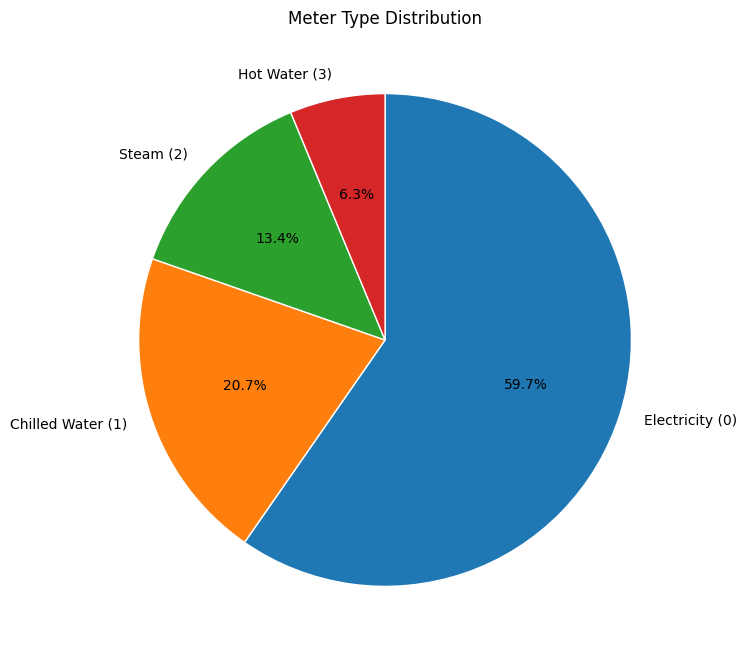

In [6]:
meter_labels = {
    0: "Electricity (0)",
    1: "Chilled Water (1)",
    2: "Steam (2)",
    3: "Hot Water (3)",
}

meter_counts = train["meter"].value_counts().sort_index()
labels = [meter_labels.get(meter, f"Meter {meter}") for meter in meter_counts.index]

plt.figure(figsize=(8, 8))
plt.pie(
    meter_counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white"}
 )
plt.title("Meter Type Distribution")
plt.show()

#### METER READING DISTRIBUTION THROUGH TIMELINE 

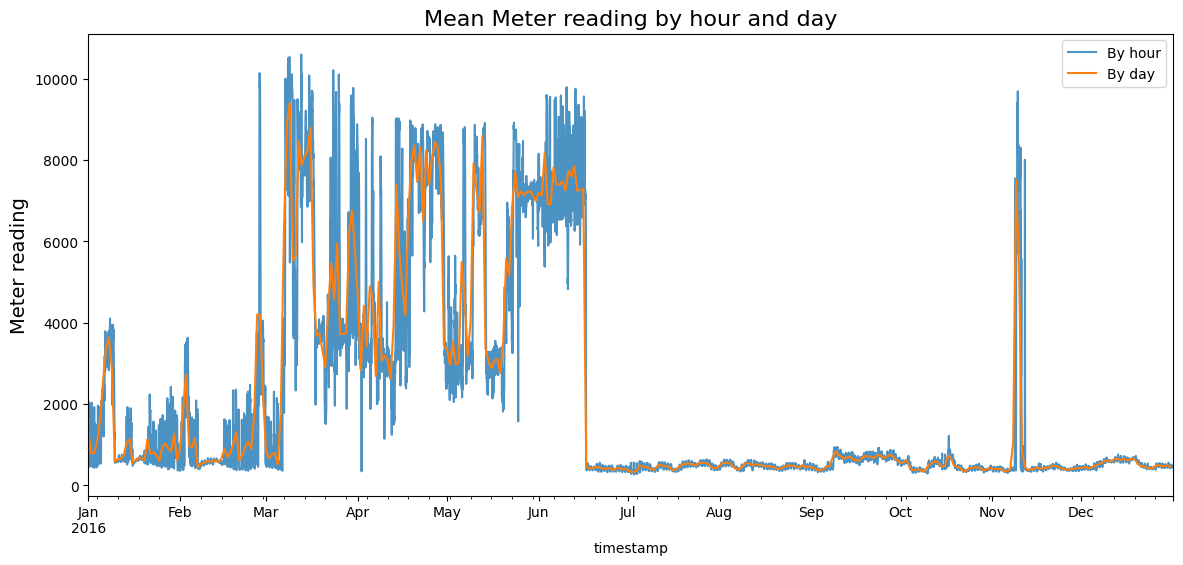

In [7]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6), dpi=100)
train[['timestamp', 'meter_reading']].set_index('timestamp').resample('h').mean()['meter_reading'].plot(ax=axes, label='By hour', alpha=0.8).set_ylabel('Meter reading', fontsize=14);
train[['timestamp', 'meter_reading']].set_index('timestamp').resample('D').mean()['meter_reading'].plot(ax=axes, label='By day', alpha=1).set_ylabel('Meter reading', fontsize=14);
axes.set_title('Mean Meter reading by hour and day', fontsize=16);
axes.legend();

#### CHECK AVERAGE ENERGY CONSUMPTION FOR WEEKDAY (NOT ONLY 0 RECORDS)

C:\Users\eEren\AppData\Local\Temp\ipykernel_18924\4047439260.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


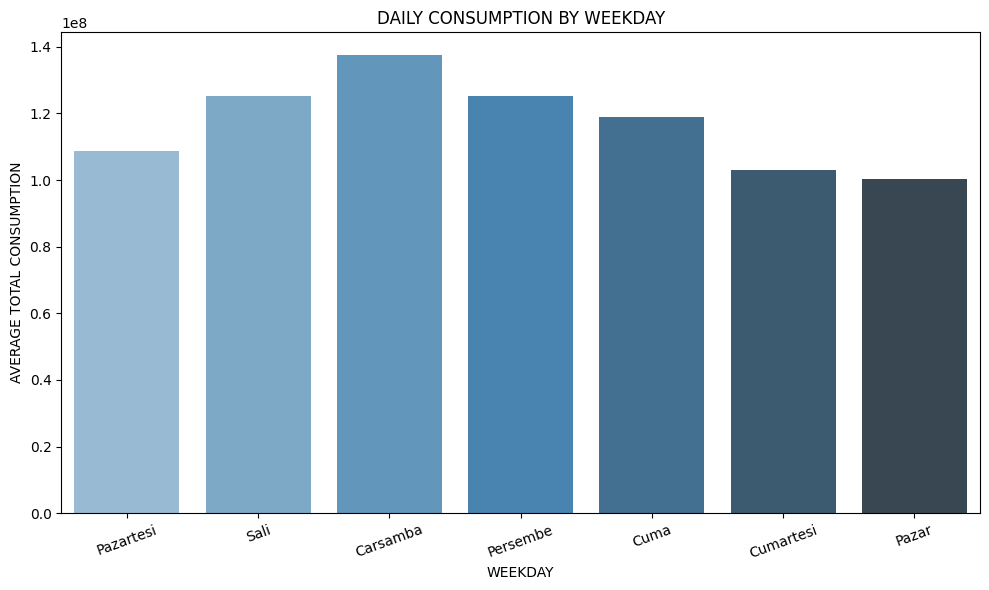

In [8]:
daily_total_consumption = (
    train.groupby(train["timestamp"].dt.normalize())["meter_reading"]
    .sum()
    .reset_index(name="gunluk_toplam_tuketim")
    .rename(columns={"timestamp": "gun"})
)

gun_isimleri = {
    0: "Pazartesi",
    1: "Sali",
    2: "Carsamba",
    3: "Persembe",
    4: "Cuma",
    5: "Cumartesi",
    6: "Pazar",
}

daily_total_consumption["haftanin_gunu_kodu"] = daily_total_consumption["gun"].dt.dayofweek
daily_total_consumption["haftanin_gunu"] = daily_total_consumption["haftanin_gunu_kodu"].map(gun_isimleri)

weekday_average_consumption = (
    daily_total_consumption.groupby(["haftanin_gunu_kodu", "haftanin_gunu"])["gunluk_toplam_tuketim"]
    .mean()
    .reset_index(name="ortalama_toplam_tuketim")
    .sort_values("haftanin_gunu_kodu")
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=weekday_average_consumption,
    x="haftanin_gunu",
    y="ortalama_toplam_tuketim",
    palette="Blues_d"
 )
plt.title("DAILY CONSUMPTION BY WEEKDAY")
plt.xlabel("WEEKDAY")
plt.ylabel("AVERAGE TOTAL CONSUMPTION")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

#### CHECK METER READING VALUE FOR EACH METER TYPE

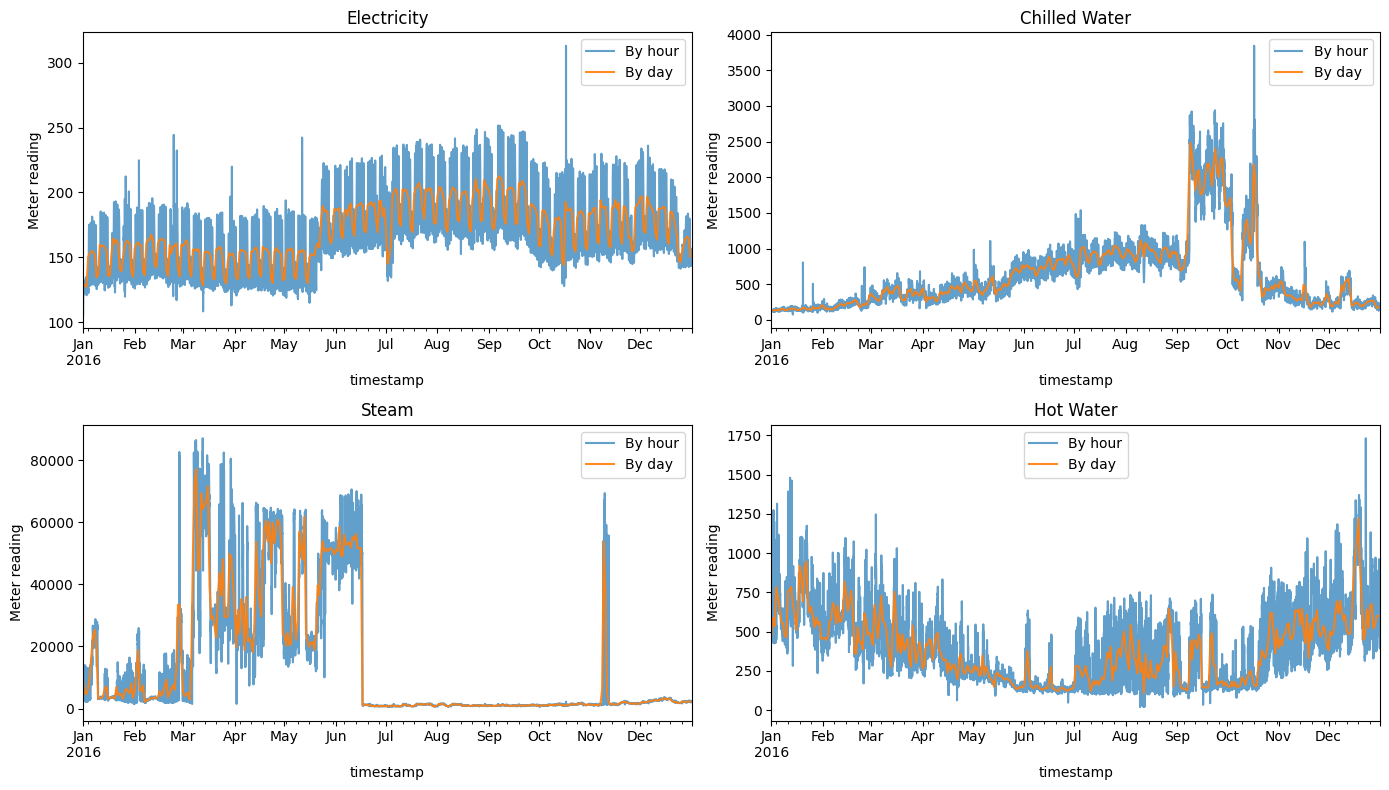

In [9]:
meter_frames = {
    "Electricity": train[train["meter"] == 0],
    "Chilled Water": train[train["meter"] == 1],
    "Steam": train[train["meter"] == 2],
    "Hot Water": train[train["meter"] == 3],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), dpi=100)

for ax, (title, frame) in zip(axes.flat, meter_frames.items()):
    hourly = frame[["timestamp", "meter_reading"]].set_index("timestamp").resample("h").mean()["meter_reading"]
    daily = frame[["timestamp", "meter_reading"]].set_index("timestamp").resample("D").mean()["meter_reading"]
    hourly.plot(ax=ax, label="By hour", alpha=0.7)
    daily.plot(ax=ax, label="By day", alpha=0.9)
    ax.set_title(title)
    ax.set_ylabel("Meter reading")
    ax.legend()

plt.tight_layout()
plt.show()

#### IMPORTANT INSIGHT => STEAM METER READING SHOWS SAME PATTERN WITH ALL METER READING

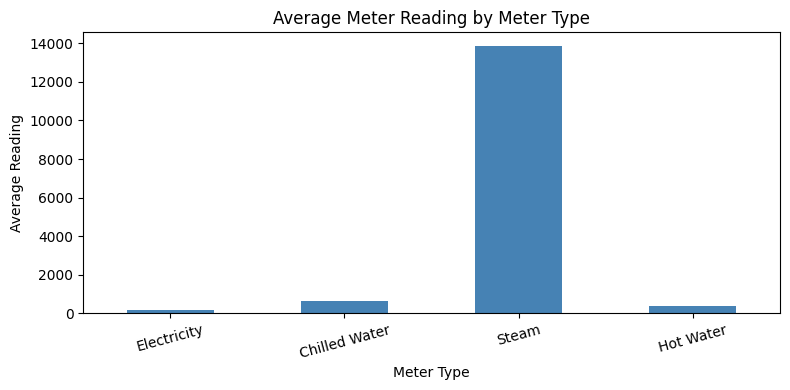

In [10]:
meter_avg = train.groupby("meter")["meter_reading"].mean()
meter_avg.index = ["Electricity", "Chilled Water", "Steam", "Hot Water"]

ax = meter_avg.plot(kind="bar", color="steelblue", figsize=(8, 4))
ax.set_title("Average Meter Reading by Meter Type")
ax.set_xlabel("Meter Type")
ax.set_ylabel("Average Reading")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [11]:
meter_avg

Electricity        170.825636
Chilled Water      633.363924
Steam            13882.187689
Hot Water          385.866781
Name: meter_reading, dtype: float64

In [12]:
def calculate_zero_reading_percentage(meter_type) -> float:
    total_count = train[train["meter"] == meter_type].shape[0]
    zero_count = train[(train["meter"] == meter_type) & (train["meter_reading"] == 0)].shape[0]
    percentage = (zero_count / total_count) * 100 if total_count > 0 else 0
    return percentage

meter_types = {
    0: "Electricity",
    1: "Chilled Water",
    2: "Steam",
    3: "Hot Water" 
    }

for meter_code in meter_types:
    percentage = calculate_zero_reading_percentage(meter_code)
    print(f"Percentage of 0 readings for {meter_types[meter_code]}: {percentage:.2f}%")

Percentage of 0 readings for Electricity: 4.40%
Percentage of 0 readings for Chilled Water: 15.70%
Percentage of 0 readings for Steam: 12.81%
Percentage of 0 readings for Hot Water: 26.93%


In [13]:
## Merge train data with building_metadata to get building information for all meter readings

train = train.merge(building_metadata, on="building_id", how="left")

train.isnull().sum()

building_id             0
meter                   0
timestamp               0
meter_reading           0
site_id                 0
primary_use             0
square_feet             0
year_built       12127645
floor_count      16709167
dtype: int64

##### METER READING BY PRIMARY USE FOR EACH METER TYPE

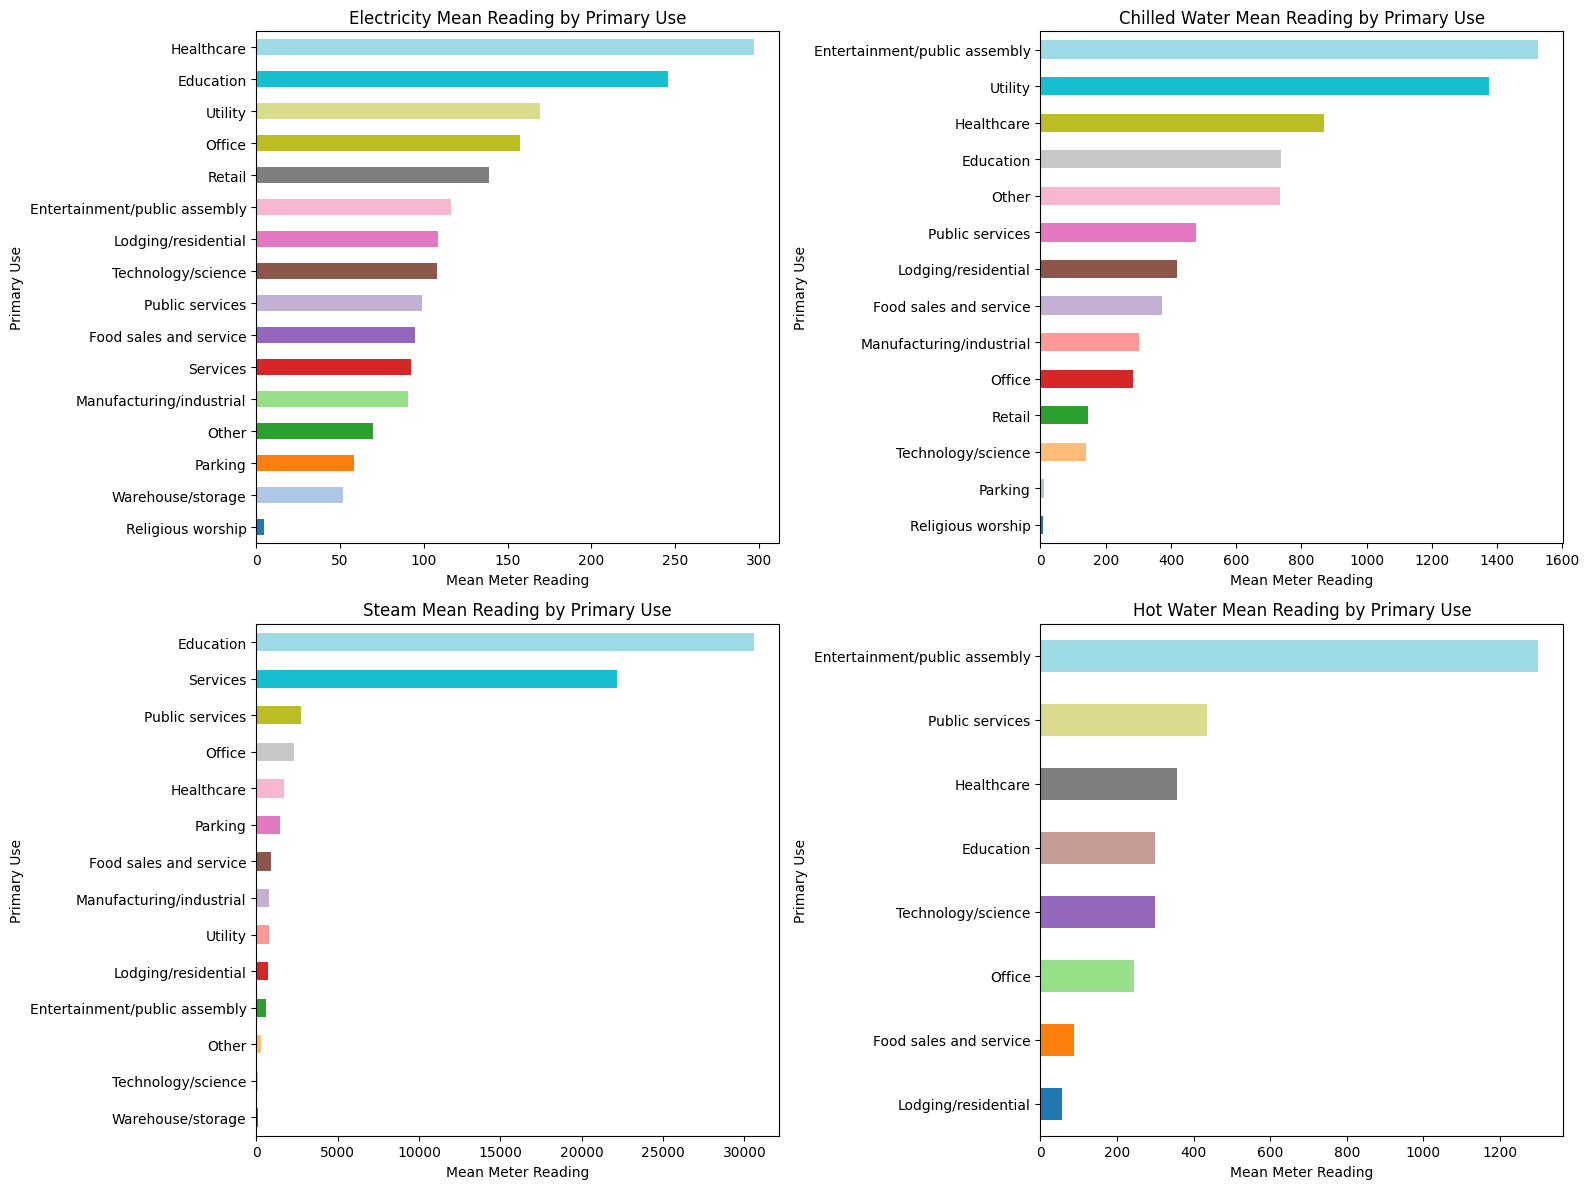

In [14]:

meter_names = {
    0: "Electricity",
    1: "Chilled Water",
    2: "Steam",
    3: "Hot Water"
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, meter in enumerate(sorted(train["meter"].dropna().unique())):
    meter_data = train[train["meter"] == meter]

    mean_by_use = (
        meter_data.groupby("primary_use")["meter_reading"]
        .mean()
        .sort_values()
    )

    colors = plt.cm.tab20(np.linspace(0, 1, len(mean_by_use)))

    mean_by_use.plot(
        kind="barh",
        ax=axes[i],
        color=colors
    )

    axes[i].set_title(f'{meter_names.get(meter, f"Meter {meter}")} Mean Reading by Primary Use')
    axes[i].set_xlabel("Mean Meter Reading")
    axes[i].set_ylabel("Primary Use")

plt.tight_layout()
plt.show()

##### SITE_ID METER READING DISTRIBUTION


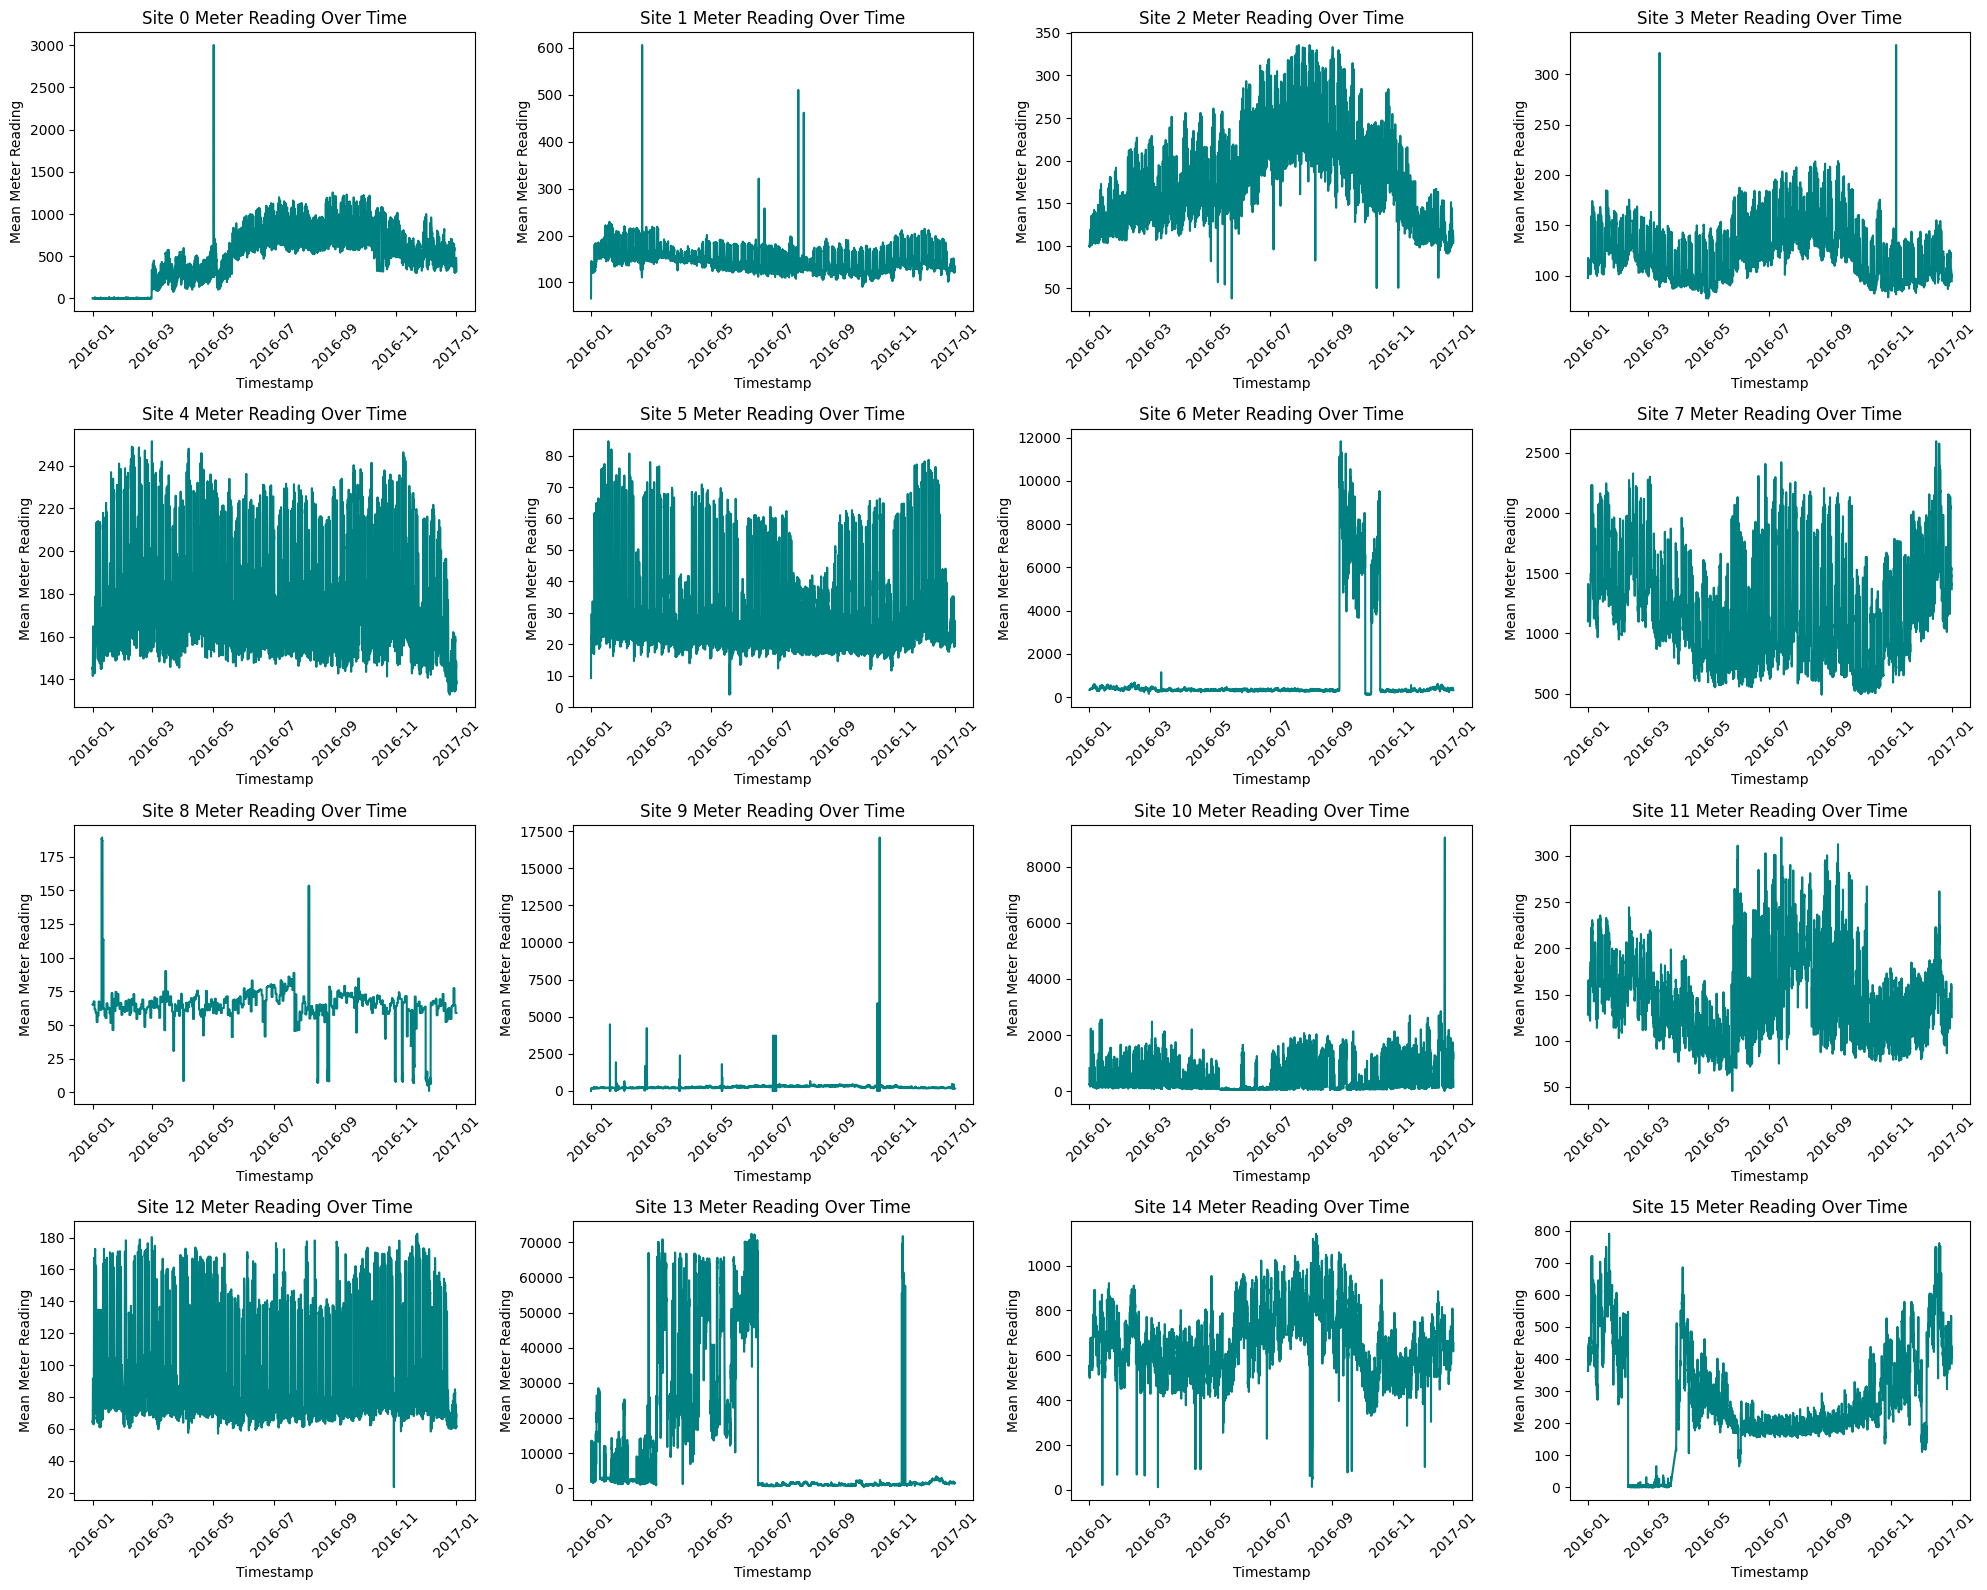

In [15]:
site_ids = sorted(train["site_id"].dropna().unique())

n_cols = 4
n_rows = int(np.ceil(len(site_ids) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = np.array(axes).flatten()

for i, site_id in enumerate(site_ids):
    site_data = train[train["site_id"] == site_id]

    time_series = (
        site_data.groupby("timestamp")["meter_reading"]
        .mean()
        .sort_index()
    )

    axes[i].plot(time_series.index, time_series.values, color="teal")
    axes[i].set_title(f"Site {site_id} Meter Reading Over Time")
    axes[i].set_xlabel("Timestamp")
    axes[i].set_ylabel("Mean Meter Reading")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### IMPORTANT INSIGHT => SITE 13 METER READING ALSO SHOWS SAME PATTERN WITH  STEAM READING AND ALL METER READING OVER TIME. THAT MEANS, ENERGY CONSUMPTION DISTRIBUTION IS NOT BALANCED.

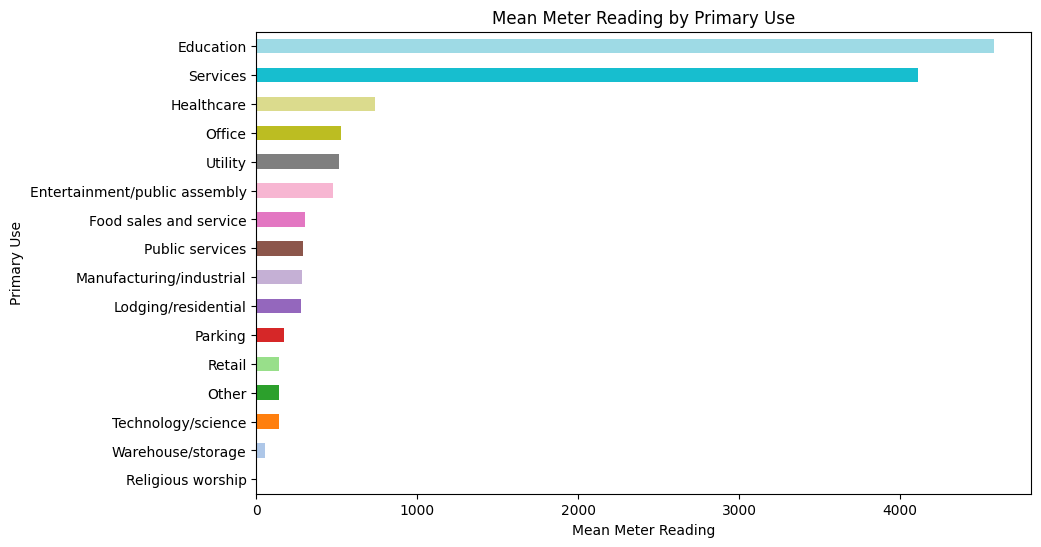

In [16]:
mean_by_primary_use = (
    train.groupby("primary_use")["meter_reading"]
    .mean()
    .sort_values()
)

colors = plt.cm.tab20(np.linspace(0, 1, len(mean_by_primary_use)))

mean_by_primary_use.plot(
    kind="barh",
    figsize=(10, 6),
    color=colors
)

plt.title("Mean Meter Reading by Primary Use")
plt.xlabel("Mean Meter Reading")
plt.ylabel("Primary Use")
plt.show()

##### METER READING OBSERVATION FOR EACH PRIMARY USAGE ACCORDING TO TIME

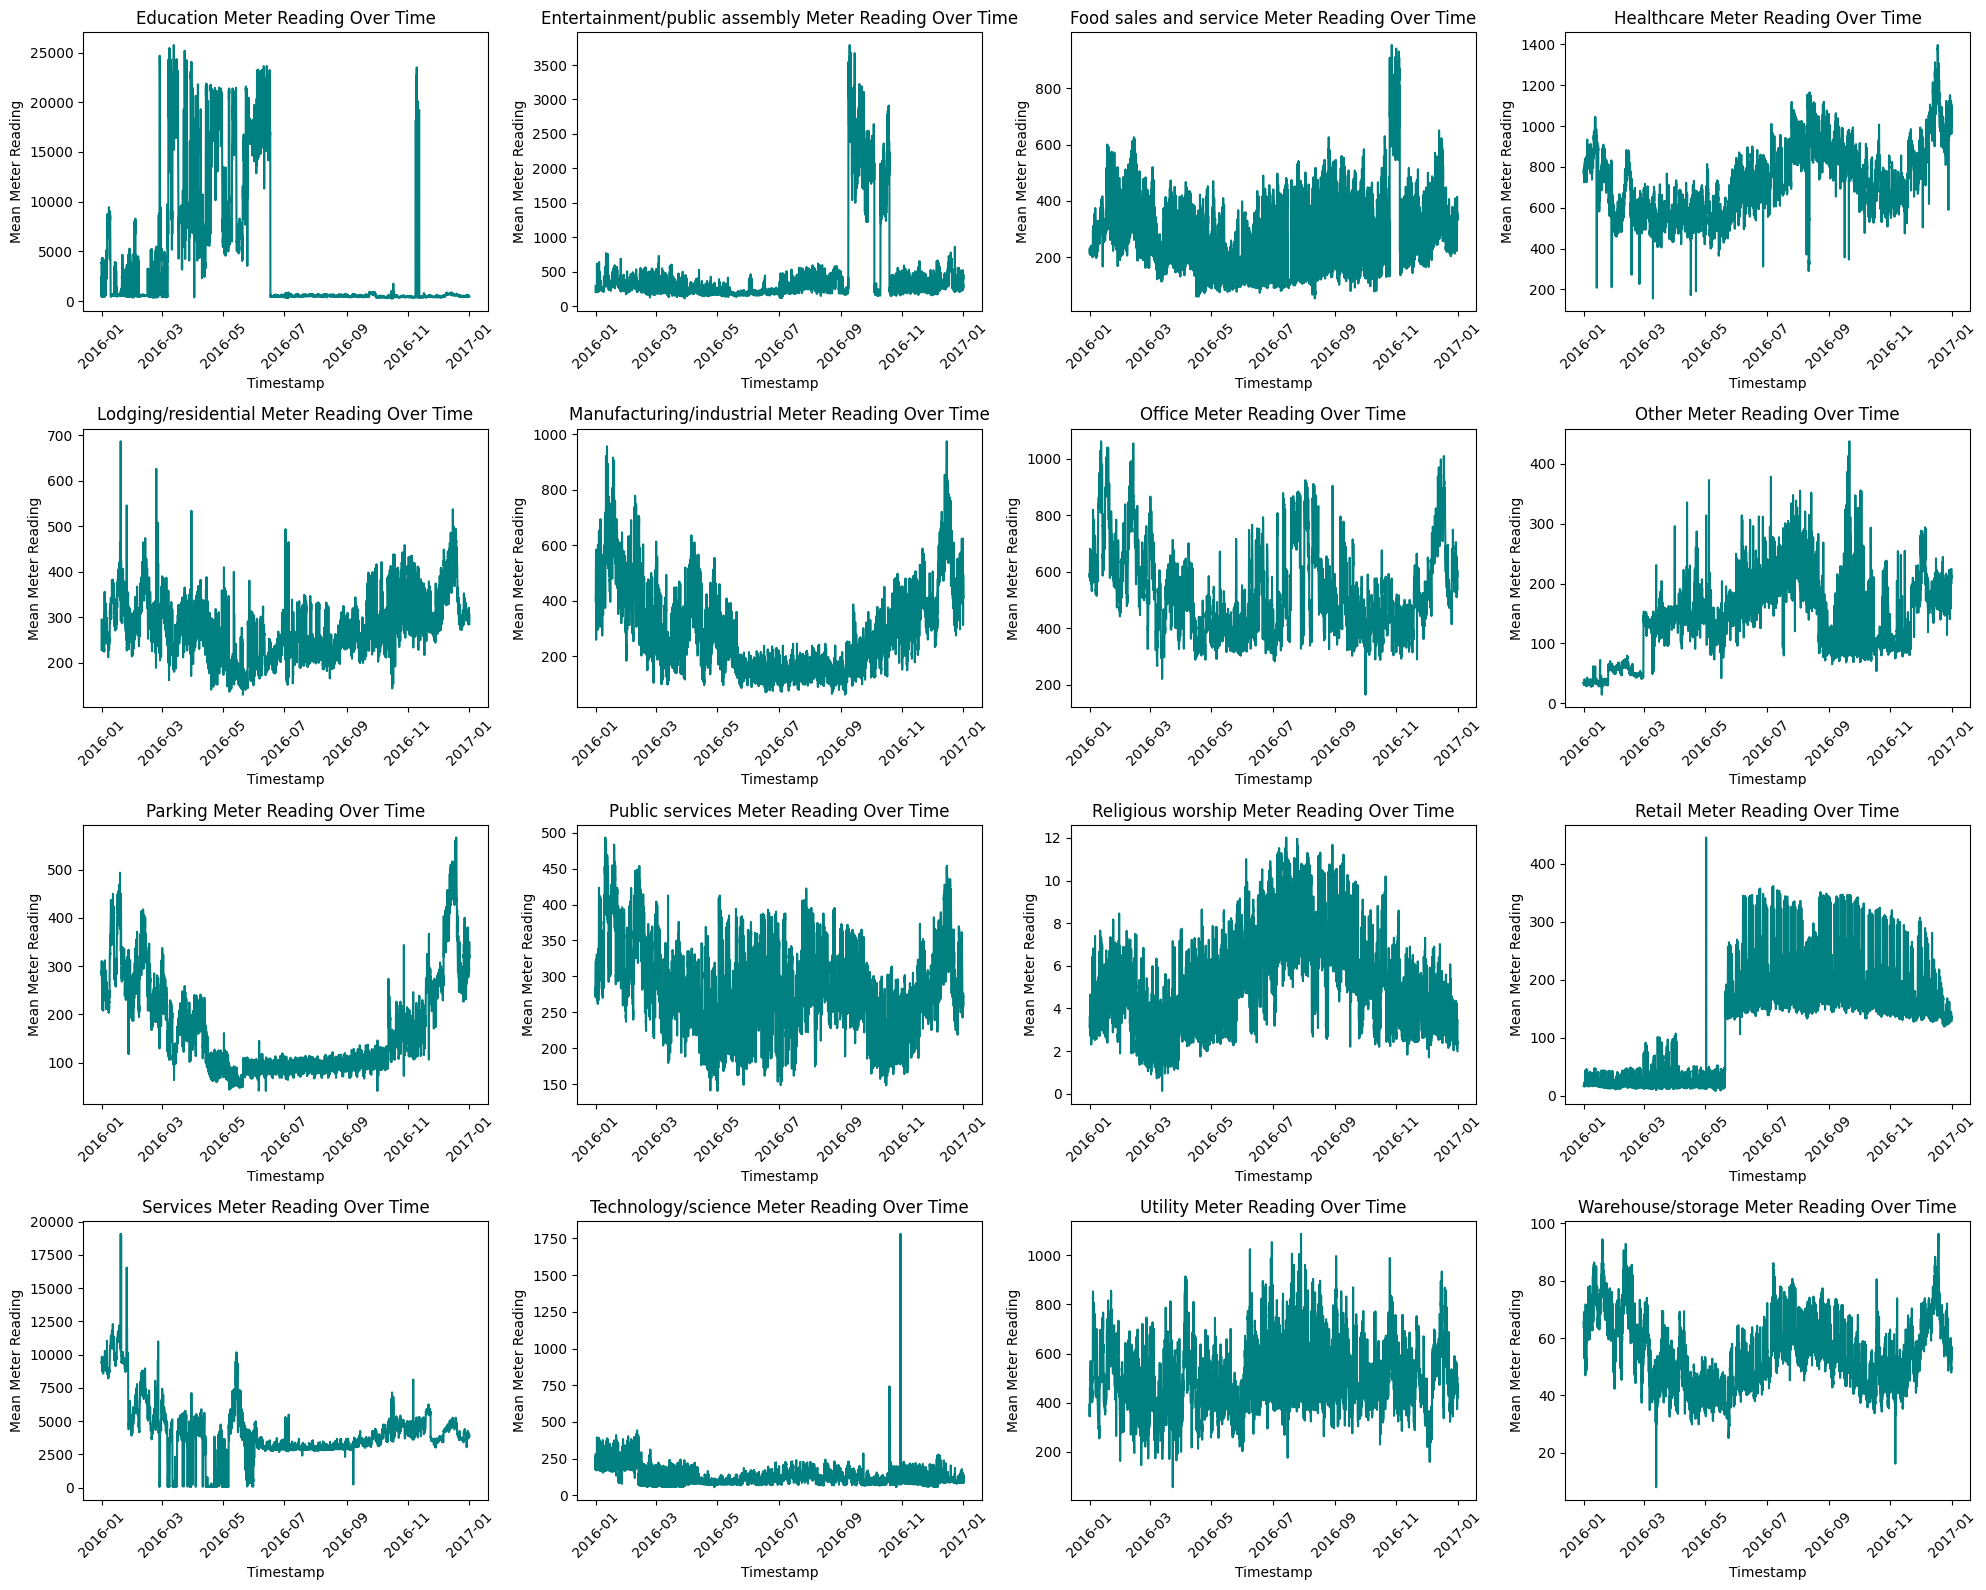

In [17]:
primary_uses = sorted(train["primary_use"].dropna().unique())

n_cols = 4
n_rows = int(np.ceil(len(primary_uses) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = np.array(axes).flatten()

for i, primary_use in enumerate(primary_uses):
    use_data = train[train["primary_use"] == primary_use]

    time_series = (
        use_data.groupby("timestamp")["meter_reading"]
        .mean()
        .sort_index()
    )

    axes[i].plot(time_series.index, time_series.values, color="teal")
    axes[i].set_title(f"{primary_use} Meter Reading Over Time")
    axes[i].set_xlabel("Timestamp")
    axes[i].set_ylabel("Mean Meter Reading")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Meter Reading Distribution

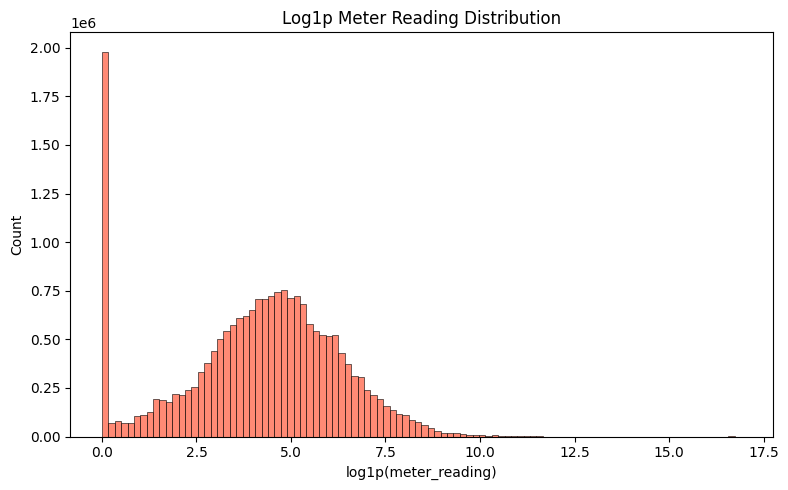

In [18]:
meter_names = {
    0: "Electricity",
    1: "Chilled Water",
    2: "Steam",
    3: "Hot Water"
}

log_meter_reading = np.log1p(train["meter_reading"])

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

sns.histplot(log_meter_reading, bins=100, ax=ax, color="tomato")
ax.set_title("Log1p Meter Reading Distribution")
ax.set_xlabel("log1p(meter_reading)")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

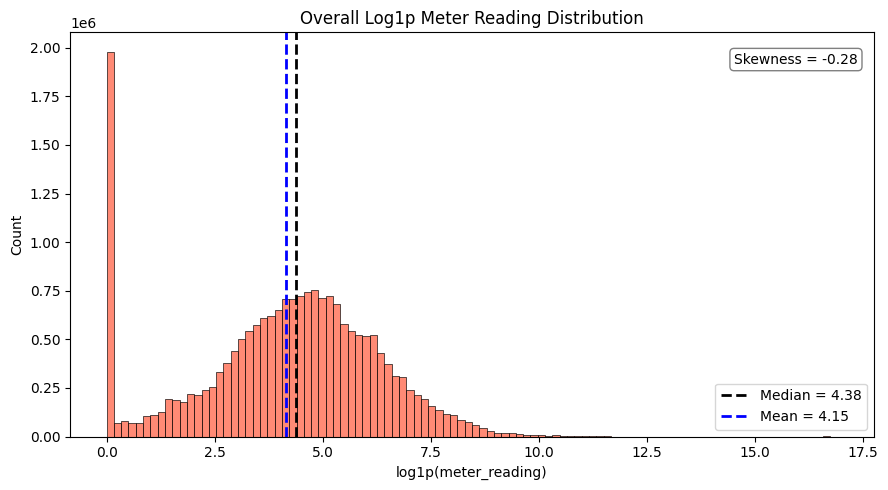

In [19]:
log_meter_reading = np.log1p(train["meter_reading"])
log_skew = log_meter_reading.skew()

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(log_meter_reading, bins=100, ax=ax, color="tomato")
ax.axvline(log_meter_reading.median(), color="black", linestyle="--", linewidth=2, label=f"Median = {log_meter_reading.median():.2f}")
ax.axvline(log_meter_reading.mean(), color="blue", linestyle="--", linewidth=2, label=f"Mean = {log_meter_reading.mean():.2f}")

ax.text(
    0.98, 0.95,
    f"Skewness = {log_skew:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
)

ax.set_title("Overall Log1p Meter Reading Distribution")
ax.set_xlabel("log1p(meter_reading)")
ax.set_ylabel("Count")
ax.legend()

plt.tight_layout()
plt.show()

In [20]:
# 6. Extreme values overall
print("Top 10 highest meter_reading values")
train["meter_reading"].nlargest(10)

# 7. Top 0.1% threshold overall
top_001_threshold = train["meter_reading"].quantile(0.999)

print(f"Top 0.1% threshold overall: {top_001_threshold:.4f}")

top_001_mask = train["meter_reading"] >= top_001_threshold

print("Top 0.1% rows count:", int(top_001_mask.sum()))
print("------------------------------")
print("\nTop 0.1% meter type distribution")
print(train.loc[top_001_mask, "meter"].map(meter_names).value_counts())



Top 10 highest meter_reading values
Top 0.1% threshold overall: 38671.9000
Top 0.1% rows count: 20220
------------------------------

Top 0.1% meter type distribution
meter
Steam            17326
Hot Water         1695
Chilled Water     1196
Electricity          3
Name: count, dtype: int64


In [21]:
# 10. Share of overall top 0.1% by meter type
top_share_by_meter = (
    train.assign(is_top_0_1_percent_overall=top_001_mask)
    .groupby("meter")["is_top_0_1_percent_overall"]
    .mean()
    .mul(100)
)
top_share_by_meter.index = top_share_by_meter.index.map(meter_names)

print("Percentage of records in the overall top 0.1% by meter type")
top_share_by_meter.sort_values(ascending=False)

Percentage of records in the overall top 0.1% by meter type


meter
Steam            0.639640
Hot Water        0.134094
Chilled Water    0.028596
Electricity      0.000025
Name: is_top_0_1_percent_overall, dtype: float64

#### METER READING DISTRIBUTION WITHOUT ZERO METER READING VALUES

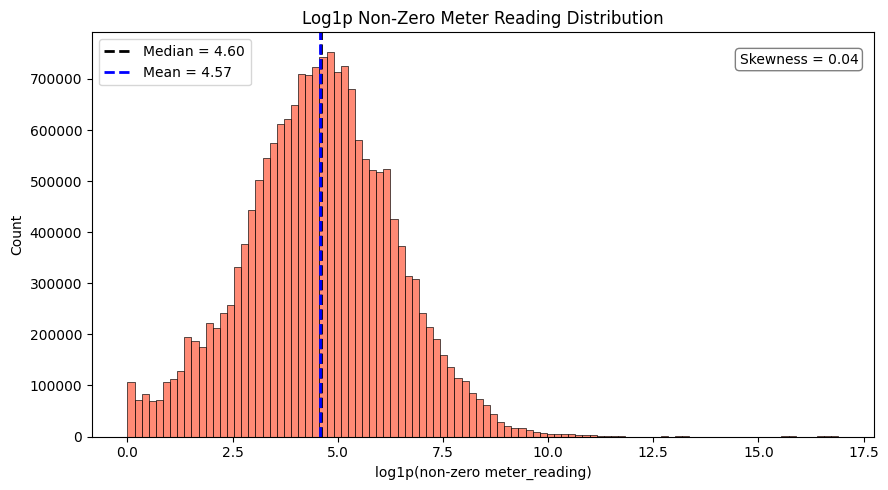

In [22]:
from scipy import stats

non_zero = train[train["meter_reading"] > 0]["meter_reading"]
log_non_zero = np.log1p(non_zero)
log_skew = log_non_zero.skew()

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(log_non_zero, bins=100, ax=ax, color="tomato")
ax.axvline(
    log_non_zero.median(),
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Median = {log_non_zero.median():.2f}"
)
ax.axvline(
    log_non_zero.mean(),
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {log_non_zero.mean():.2f}"
)

ax.text(
    0.98, 0.95,
    f"Skewness = {log_skew:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
)

ax.set_title("Log1p Non-Zero Meter Reading Distribution")
ax.set_xlabel("log1p(non-zero meter_reading)")
ax.set_ylabel("Count")
ax.legend()

plt.tight_layout()
plt.show()



### SQUARE FEET TARGET ANALYSIS

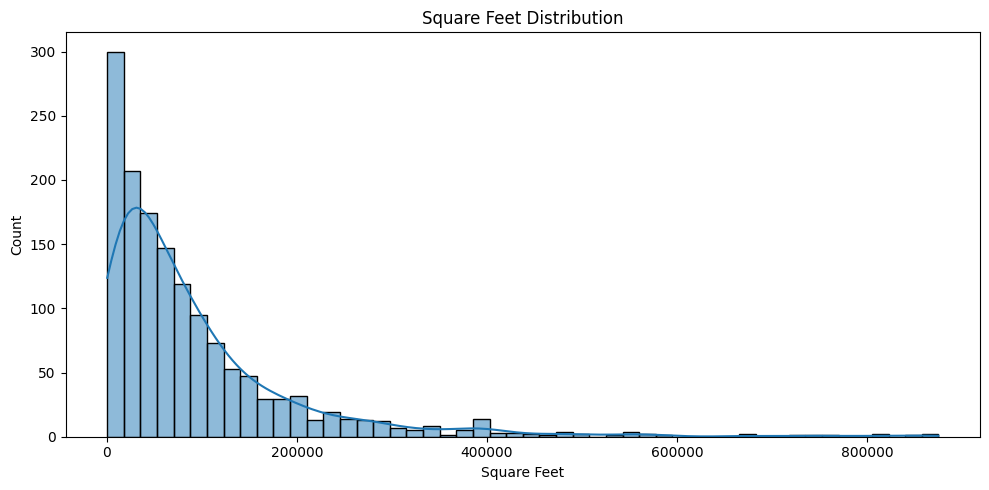

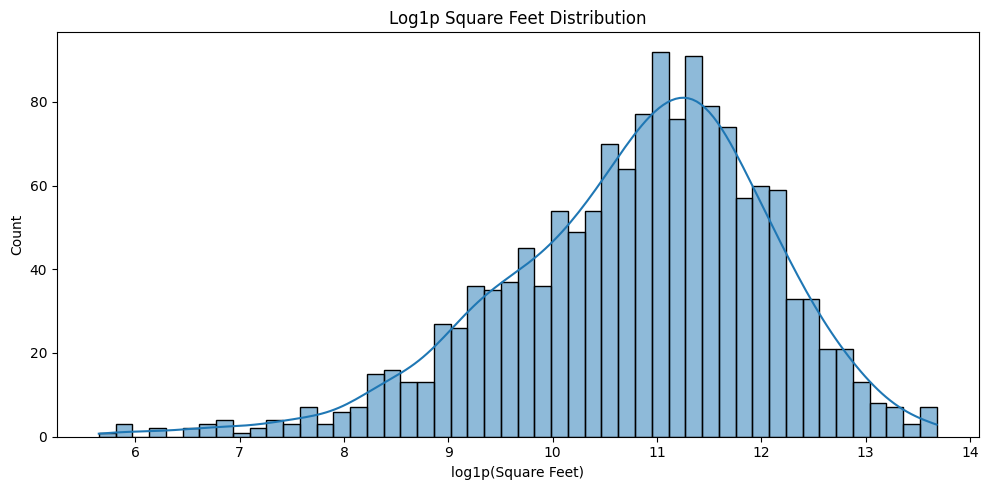

In [23]:
plt.figure(figsize=(10, 5))
sns.histplot(building_metadata["square_feet"], bins=50, kde=True)
plt.title("Square Feet Distribution")
plt.xlabel("Square Feet")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(building_metadata["square_feet"]), bins=50, kde=True)
plt.title("Log1p Square Feet Distribution")
plt.xlabel("log1p(Square Feet)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

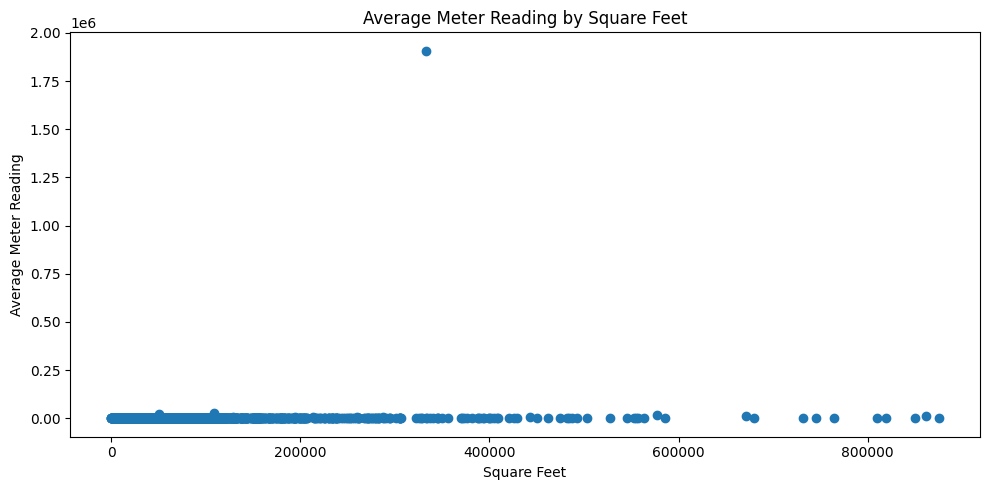

In [24]:
area_data = train[["square_feet", "meter_reading"]].dropna()

area_data.groupby("square_feet")["meter_reading"].mean().plot(
    figsize=(10, 5),
    marker="o",
    linestyle="none"
)

plt.title("Average Meter Reading by Square Feet")
plt.xlabel("Square Feet")
plt.ylabel("Average Meter Reading")
plt.tight_layout()
plt.show()

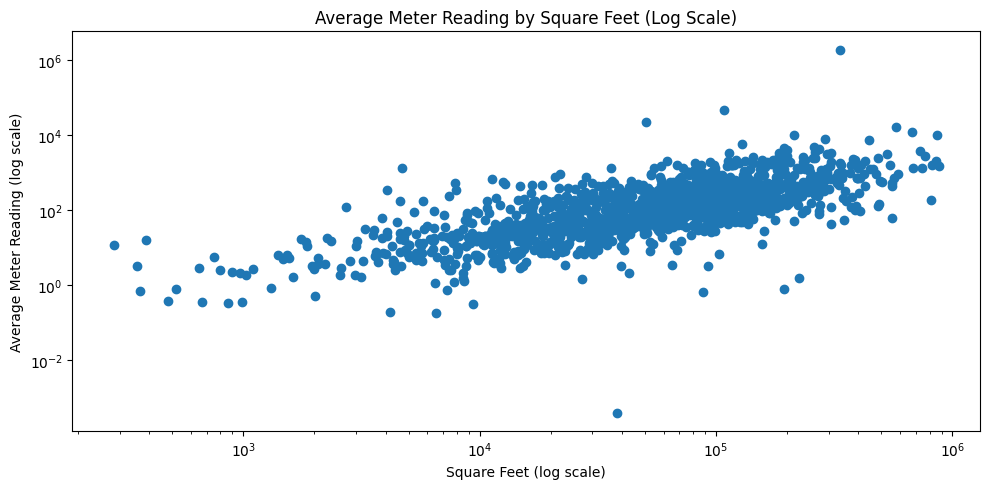

In [25]:
log_area_data = train.loc[
    (train["square_feet"] > 0) & (train["meter_reading"] > 0),
    ["square_feet", "meter_reading"]
].dropna()

avg_meter_by_area = log_area_data.groupby("square_feet")["meter_reading"].mean()

avg_meter_by_area.plot(
    figsize=(10, 5),
    marker="o",
    linestyle="none"
)

plt.xscale("log")
plt.yscale("log")
plt.title("Average Meter Reading by Square Feet (Log Scale)")
plt.xlabel("Square Feet (log scale)")
plt.ylabel("Average Meter Reading (log scale)")
plt.tight_layout()
plt.show()

### Weather Target Correlation

In [26]:
train_weather = train.merge(
    weather_data,
    on=["site_id", "timestamp"],
    how="left"
)

print(train_weather.shape)




(20216100, 16)


In [27]:
train_weather.isnull().sum()

building_id                  0
meter                        0
timestamp                    0
meter_reading                0
site_id                      0
primary_use                  0
square_feet                  0
year_built            12127645
floor_count           16709167
air_temperature          96658
cloud_coverage         8825365
dew_temperature         100140
precip_depth_1_hr      3749023
sea_level_pressure     1231669
wind_direction         1449048
wind_speed              143676
dtype: int64

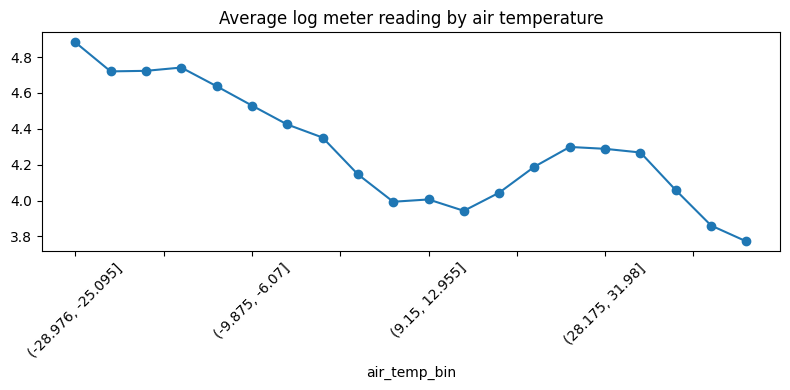

In [28]:
train_weather["log_meter_reading"] = np.log1p(train_weather["meter_reading"])

train_weather[["air_temperature", "dew_temperature", "meter_reading"]].isnull().sum()

temp_data = train_weather[["air_temperature", "log_meter_reading"]].dropna().copy()
temp_data["air_temp_bin"] = pd.cut(temp_data["air_temperature"], bins=20)

temp_data.groupby("air_temp_bin")["log_meter_reading"].mean().plot(figsize=(8,4), marker="o")
plt.title("Average log meter reading by air temperature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

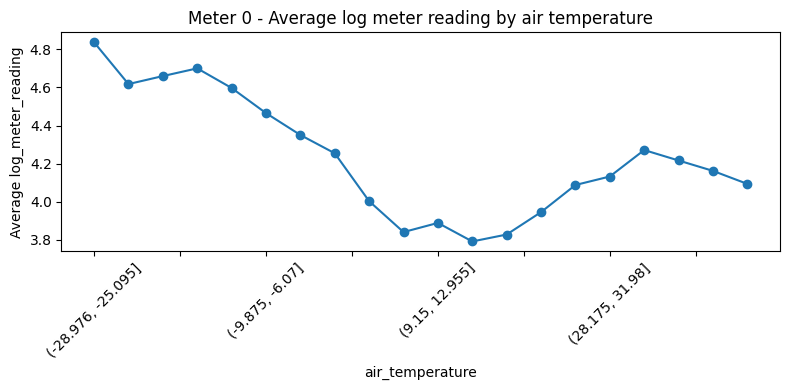

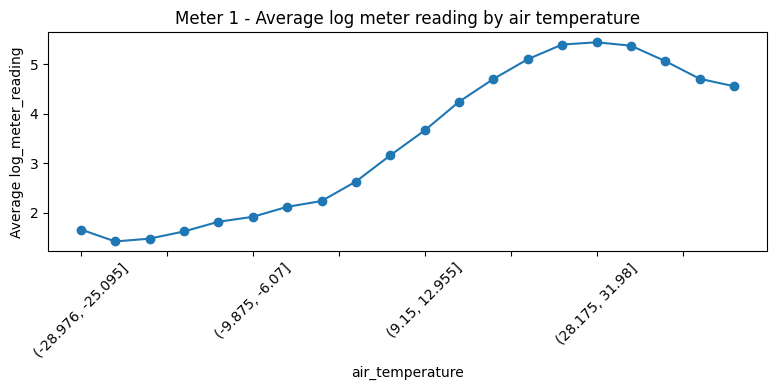

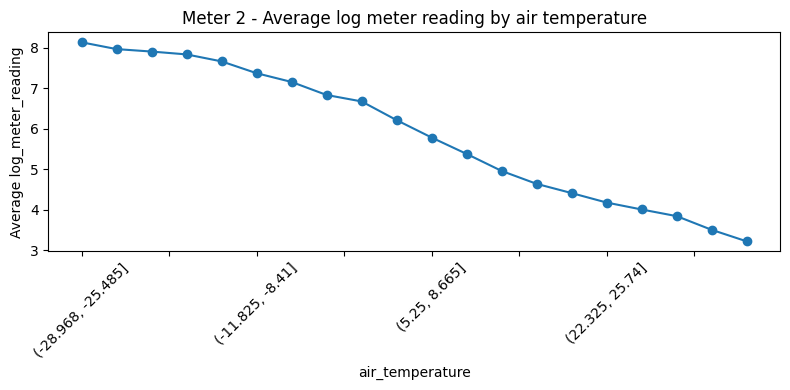

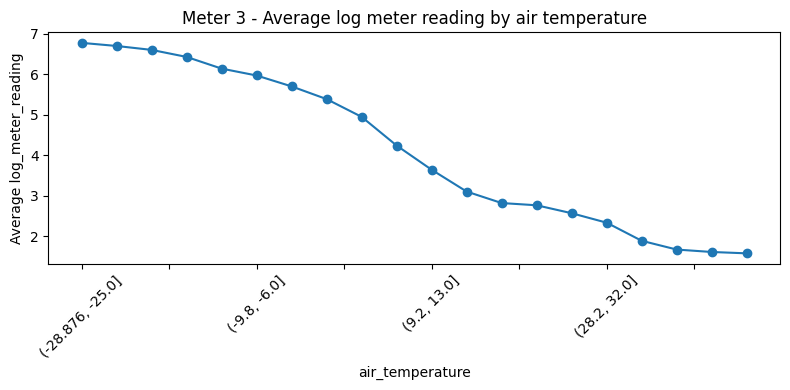

In [29]:
for m in sorted(train_weather["meter"].dropna().unique()):
    temp = train_weather[train_weather["meter"] == m][["air_temperature",
"log_meter_reading"]].dropna().copy()
    temp["air_temp_bin"] = pd.cut(temp["air_temperature"], bins=20)

    avg_usage = temp.groupby("air_temp_bin")["log_meter_reading"].mean()

    plt.figure(figsize=(8, 4))
    avg_usage.plot(marker="o")
    plt.title(f"Meter {m} - Average log meter reading by air temperature")
    plt.xlabel("air_temperature")
    plt.ylabel("Average log_meter_reading")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


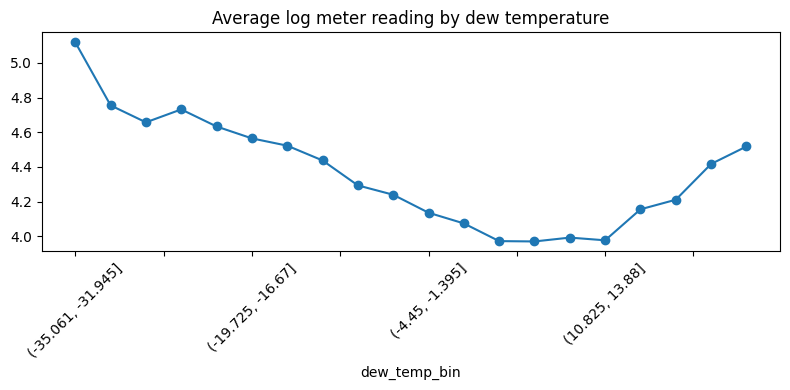

In [30]:
train_weather["log_meter_reading"] = np.log1p(train["meter_reading"])

train_weather[["dew_temperature", "meter_reading"]].isnull().sum()

temp_data = train_weather[["dew_temperature", "log_meter_reading"]].dropna().copy()
temp_data["dew_temp_bin"] = pd.cut(temp_data["dew_temperature"], bins=20)

temp_data.groupby("dew_temp_bin")["log_meter_reading"].mean().plot(figsize=(8,4), marker="o")
plt.title("Average log meter reading by dew temperature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

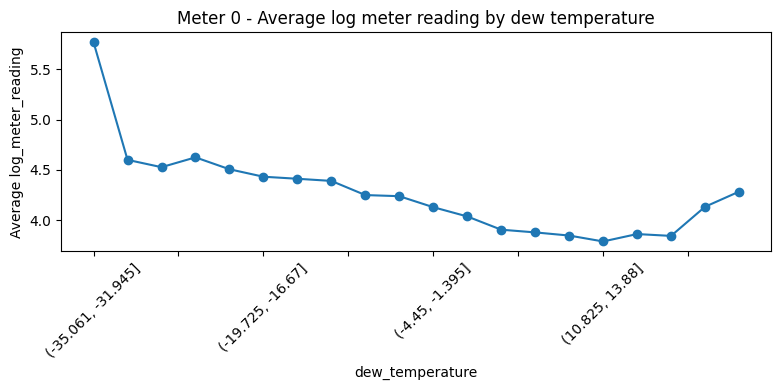

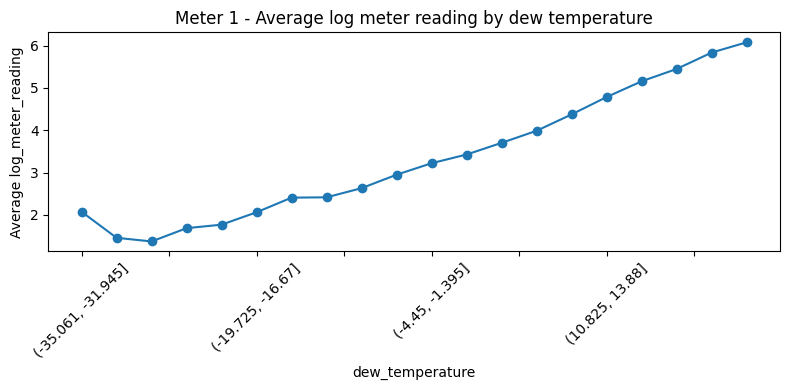

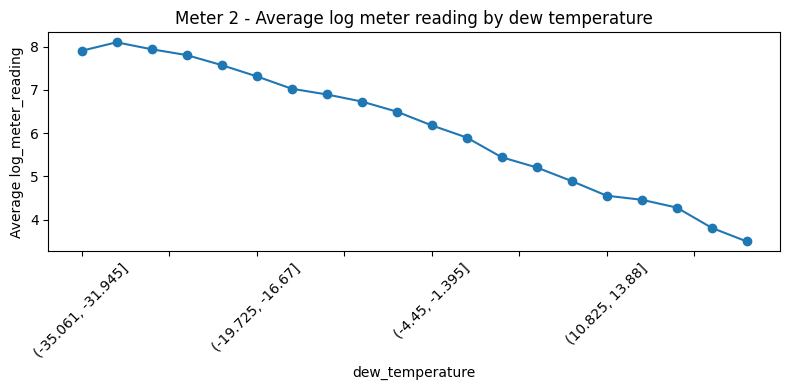

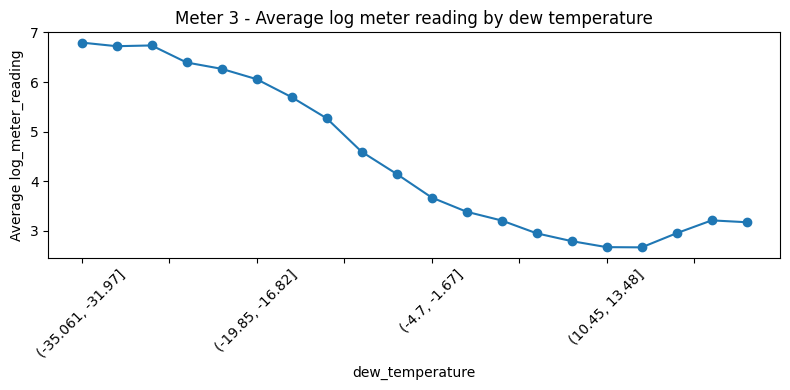

In [31]:
for m in sorted(train_weather["meter"].dropna().unique()):
    temp = train_weather[train_weather["meter"] == m][["dew_temperature",
"log_meter_reading"]].dropna().copy()
    temp["dew_temp_bin"] = pd.cut(temp["dew_temperature"], bins=20)

    avg_usage = temp.groupby("dew_temp_bin")["log_meter_reading"].mean()

    plt.figure(figsize=(8, 4))
    avg_usage.plot(marker="o")
    plt.title(f"Meter {m} - Average log meter reading by dew temperature")
    plt.xlabel("dew_temperature")
    plt.ylabel("Average log_meter_reading")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [32]:
weather_cols = ["air_temperature", "dew_temperature"]

train_weather.groupby("meter").apply(
    lambda x: x[["log_meter_reading"] + weather_cols]
    .dropna()
    .corr()
    .loc[weather_cols, "log_meter_reading"]
)

log_meter_reading,air_temperature,dew_temperature
meter,,
0,-0.003754,-0.039955
1,0.433415,0.429479
2,-0.407453,-0.390545
3,-0.417546,-0.220993


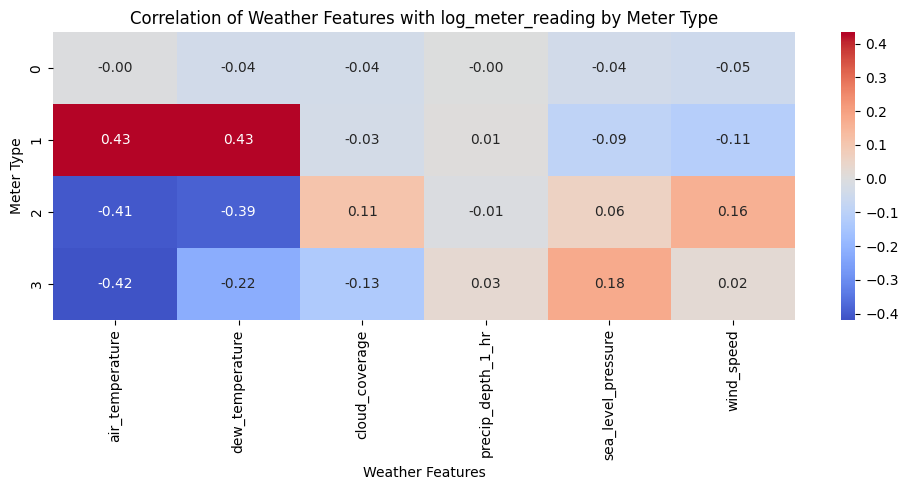

In [33]:
weather_cols = [
    "air_temperature",
    "dew_temperature",
    "cloud_coverage",
    "precip_depth_1_hr",
    "sea_level_pressure",
    "wind_speed"
]

corr_table = train_weather.groupby("meter").apply(
    lambda df: pd.Series({
        col: df[["log_meter_reading", col]].dropna().corr().iloc[0, 1]
        for col in weather_cols
    })
)

plt.figure(figsize=(10, 5))
sns.heatmap(corr_table, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation of Weather Features with log_meter_reading by Meter Type")
plt.xlabel("Weather Features")
plt.ylabel("Meter Type")
plt.tight_layout()
plt.show()

#### There is no correlation between meter reading with other weather features except air_temperature and dew_temperature.

In [34]:
import sys


## Most 5 heavy variables in memory
rows = []
skip = {"In", "Out", "get_ipython", "exit", "quit", "rows", "skip"}

for name, value in list(globals().items()):
    if name.startswith("_") or name in skip:
        continue
    try:
        if isinstance(value, pd.DataFrame):
            size_mb = value.memory_usage(deep=True).sum() / 1024**2
        elif isinstance(value, pd.Series):
            size_mb = value.memory_usage(deep=True) / 1024**2
        elif isinstance(value, np.ndarray):
            size_mb = value.nbytes / 1024**2
        else:
            size_mb = sys.getsizeof(value) / 1024**2
        rows.append((name, type(value).__name__, round(size_mb, 3)))
    except Exception:
        pass

pd.DataFrame(rows, columns=["name", "type", "memory_mb"]).sort_values("memory_mb", ascending=False).head(20)


,name,type,memory_mb
63,train_weather,DataFrame,1330.292
7,train,DataFrame,636.228
64,temp_data,DataFrame,402.866
61,log_area_data,DataFrame,349.848
58,non_zero,Series,279.879
59,log_non_zero,Series,279.879
60,area_data,DataFrame,231.355
52,log_meter_reading,Series,154.237
46,site_data,DataFrame,70.971
39,meter_data,DataFrame,49.426


In [35]:
del train,temp_data,log_area_data,non_zero,log_non_zero,area_data,log_meter_reading

gc.collect()

52041

In [36]:
test = pd.read_csv("../data/test.csv", parse_dates=["timestamp"])
weather_test = pd.read_csv("../data/weather_test.csv", parse_dates=["timestamp"])
if "reduce_mem_usage" in globals():
    test = reduce_mem_usage(test)
    weather_test = reduce_mem_usage(weather_test)

test = test.merge(building_metadata, on="building_id", how="left")
test_weather = test.merge(weather_test, on=["site_id", "timestamp"], how="left")


Memory usage of dataframe is 1272.51 MB


C:\Users\eEren\AppData\Local\Temp\ipykernel_18924\74795618.py:19: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_datetime64_any_dtype(s) or is_categorical_dtype(dtype):


Memory usage after optimization is: 596.49 MB
Decreased by 53.1%
Memory usage of dataframe is 19.04 MB
Memory usage after optimization is: 9.78 MB
Decreased by 48.6%


C:\Users\eEren\AppData\Local\Temp\ipykernel_18924\74795618.py:19: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_datetime64_any_dtype(s) or is_categorical_dtype(dtype):
C:\Users\eEren\AppData\Local\Temp\ipykernel_18924\74795618.py:19: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_datetime64_any_dtype(s) or is_categorical_dtype(dtype):
C:\Users\eEren\AppData\Local\Temp\ipykernel_18924\74795618.py:19: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_datetime64_any_dtype(s) or is_categorical_dtype(dtype):
C:\Users\eEren\AppData\Local\Temp\ipykernel_18924\74795618.py:19: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, p

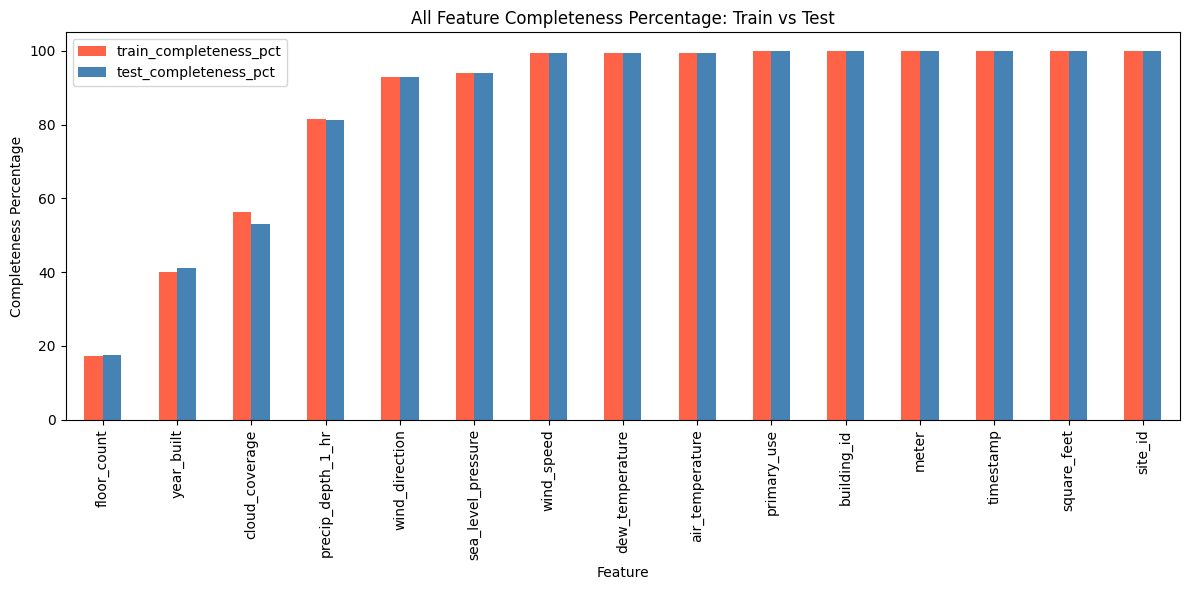

In [37]:
shared_feature_cols = sorted((set(train_weather.columns) - {"meter_reading", "log_meter_reading"}) & set(test_weather.columns))

completeness_parity = pd.DataFrame({
    "train_completeness_pct": (1 - train_weather[shared_feature_cols].isnull().mean()) * 100,
    "test_completeness_pct": (1 - test_weather[shared_feature_cols].isnull().mean()) * 100
})
completeness_parity["min_completeness_pct"] = completeness_parity[["train_completeness_pct", "test_completeness_pct"]].min(axis=1)
completeness_parity = completeness_parity.sort_values("min_completeness_pct", ascending=True)

ax = completeness_parity[["train_completeness_pct", "test_completeness_pct"]].plot(
    kind="bar",
    figsize=(max(12, len(completeness_parity) * 0.35), 6),
    color=["tomato", "steelblue"]
)
ax.set_title("All Feature Completeness Percentage: Train vs Test")
ax.set_xlabel("Feature")
ax.set_ylabel("Completeness Percentage")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
